# Batch JSON → Binary Mask Conversion

Converts LabelMe JSON annotations into binary PNG masks for DINOv2 Experiment 2.

**Mask:** `255 = leaf`, `0 = non-leaf/background`.

Expected folders:

```text
data/
├── annotations/   # *.json
└── masks/         # generated *.png
```

`image001.json` → `image001.png`

In [8]:
from pathlib import Path
import json
import numpy as np
from PIL import Image, ImageDraw
from tqdm.auto import tqdm

ANNOTATION_DIR = Path('D:/Vipin/zoom_level_detector/experiments/8.3.dinov2_leaf_experiment3/data/cotton_no_disease_data/2.test')
MASK_DIR = Path('D:/Vipin/zoom_level_detector/experiments/8.3.dinov2_leaf_experiment3/data/cotton_no_disease_data/2.test/masks')
LEAF_LABEL = 'leaf'
MASK_DIR.mkdir(parents=True, exist_ok=True)

print('Annotations:', ANNOTATION_DIR.resolve())
print('Masks:', MASK_DIR.resolve())

Annotations: D:\Vipin\zoom_level_detector\experiments\8.3.dinov2_leaf_experiment3\data\cotton_no_disease_data\2.test
Masks: D:\Vipin\zoom_level_detector\experiments\8.3.dinov2_leaf_experiment3\data\cotton_no_disease_data\2.test\masks


In [9]:
def json_to_mask(json_path, mask_path, leaf_label='leaf'):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    width = int(data['imageWidth'])
    height = int(data['imageHeight'])
    mask = Image.new('L', (width, height), 0)
    draw = ImageDraw.Draw(mask)
    leaf_shapes = 0

    for shape in data.get('shapes', []):
        label = str(shape.get('label', '')).strip().lower()
        if label != leaf_label.lower():
            continue
        points = shape.get('points', [])
        if len(points) < 3:
            continue
        polygon = [(float(x), float(y)) for x, y in points]
        draw.polygon(polygon, fill=255)
        leaf_shapes += 1

    mask.save(mask_path)
    return width, height, leaf_shapes

In [10]:
json_files = sorted(ANNOTATION_DIR.glob('*.json'))
print(f'Found {len(json_files)} JSON files.')
for p in json_files[:10]:
    print(' ', p.name)

Found 21 JSON files.
  06fe68a74c259901.json
  0b9dce91f17f1bd5.json
  0c2cbca3939e1b1d.json
  1b71d1197d9cf8a4.json
  1f3f3555147d1cb3.json
  2 (2).json
  2 (3).json
  3 (2).json
  3f1309a9a77645d0.json
  3f5f7543dff45e70.json


In [11]:
results = []
errors = []

for json_path in tqdm(json_files, desc='JSON → mask'):
    mask_path = MASK_DIR / f'{json_path.stem}.png'
    try:
        w, h, n = json_to_mask(json_path, mask_path, LEAF_LABEL)
        results.append((json_path.name, mask_path.name, w, h, n))
    except Exception as e:
        errors.append((json_path.name, repr(e)))

print(f'Successful: {len(results)}')
print(f'Errors: {len(errors)}')
for item in errors:
    print(item)

JSON → mask:   0%|          | 0/21 [00:00<?, ?it/s]

Successful: 21
Errors: 0


In [12]:
# Verify masks and calculate leaf coverage
mask_files = sorted(MASK_DIR.glob('*.png'))

for p in mask_files:
    arr = np.asarray(Image.open(p).convert('L'))
    leaf = int((arr == 255).sum())
    total = arr.size
    values = set(np.unique(arr).tolist())
    print(f'{p.name:30s} coverage={100*leaf/total:6.2f}% values={sorted(values)}')

06fe68a74c259901.png           coverage= 15.58% values=[0, 255]
0b9dce91f17f1bd5.png           coverage= 20.13% values=[0, 255]


0c2cbca3939e1b1d.png           coverage= 45.06% values=[0, 255]
1b71d1197d9cf8a4.png           coverage=  9.73% values=[0, 255]
1f3f3555147d1cb3.png           coverage=  5.95% values=[0, 255]
2 (2).png                      coverage= 37.24% values=[0, 255]
2 (3).png                      coverage= 50.00% values=[0, 255]
3 (2).png                      coverage= 42.35% values=[0, 255]
3f1309a9a77645d0.png           coverage=  6.68% values=[0, 255]
3f5f7543dff45e70.png           coverage= 43.79% values=[0, 255]
3f7f11b7722fd467.png           coverage=  0.60% values=[0, 255]
3f967db7d06a0133.png           coverage= 11.15% values=[0, 255]
4 (2).png                      coverage= 42.95% values=[0, 255]
4.png                          coverage= 55.14% values=[0, 255]
4a52a1eadcc9ac81.png           coverage=  3.91% values=[0, 255]
4a6d8903cf874a44.png           coverage=  9.54% values=[0, 255]
4cb69c1824e3e59d.png           coverage= 36.41% values=[0, 255]
5 (2).png                      coverage=

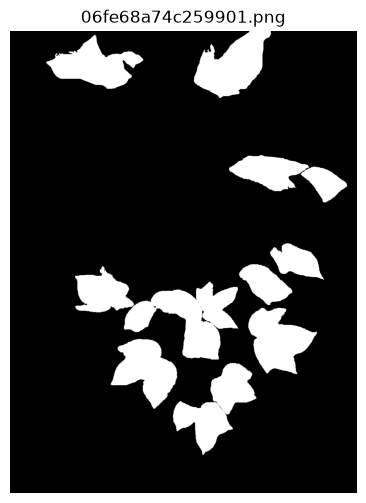

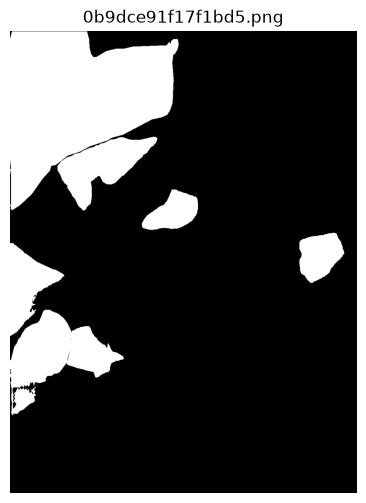

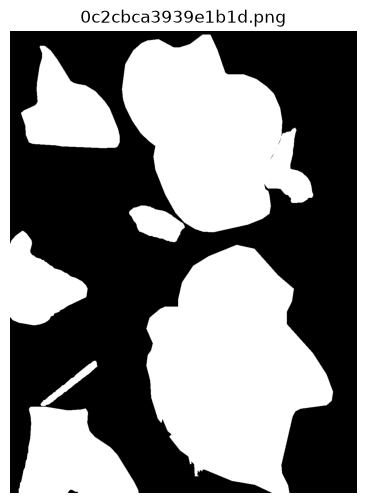

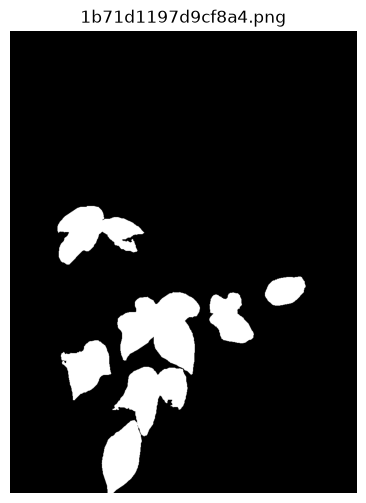

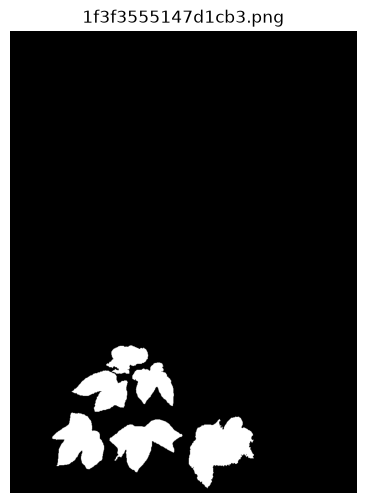

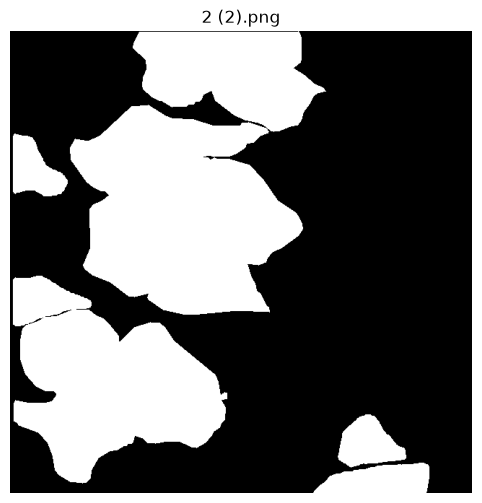

In [13]:
# Visual inspection of the first few masks
import matplotlib.pyplot as plt

for p in mask_files[:6]:
    arr = np.asarray(Image.open(p).convert('L'))
    plt.figure(figsize=(8, 6))
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
    plt.title(p.name)
    plt.axis('off')
    plt.show()

In [14]:
# Save a CSV summary
import csv

summary_file = MASK_DIR / 'mask_summary.csv'
with open(summary_file, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['mask', 'width', 'height', 'leaf_pixels', 'total_pixels', 'leaf_coverage_percent'])
    for p in mask_files:
        arr = np.asarray(Image.open(p).convert('L'))
        leaf = int((arr == 255).sum())
        writer.writerow([p.name, arr.shape[1], arr.shape[0], leaf, arr.size, 100*leaf/arr.size])

print('Saved:', summary_file.resolve())

Saved: D:\Vipin\zoom_level_detector\experiments\8.3.dinov2_leaf_experiment3\data\cotton_no_disease_data\2.test\masks\mask_summary.csv


## Next step

Check a few visualized masks carefully. Then train Experiment 2:

```bash
python scripts/train.py --config configs/config.yaml
```

The image/mask pairing must match:

`data/images/image001.jpg` ↔ `data/masks/image001.png`